Saving data.csv.csv to data.csv (4).csv


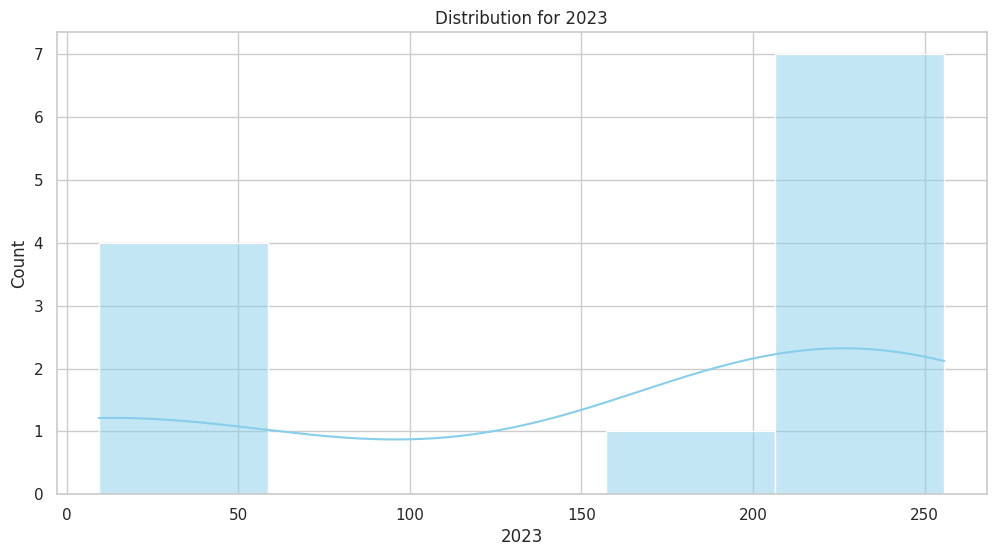

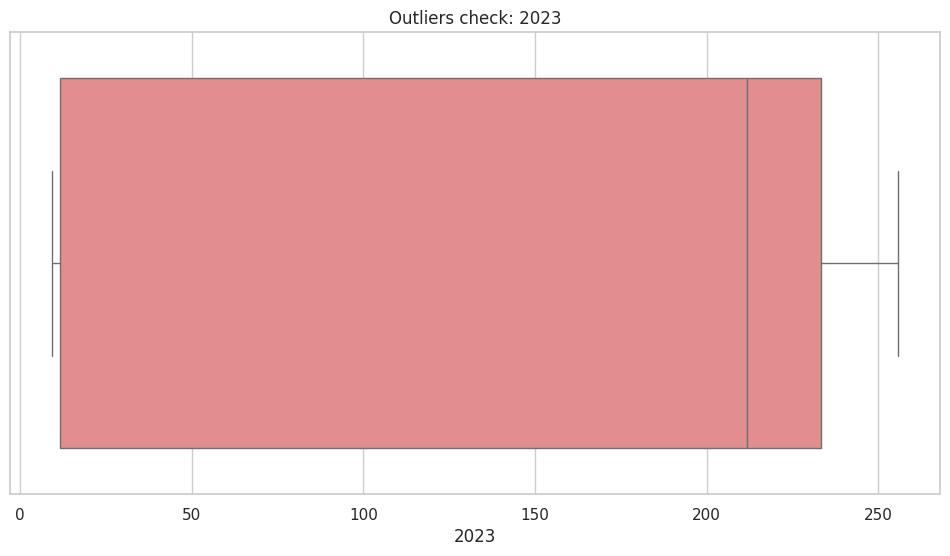

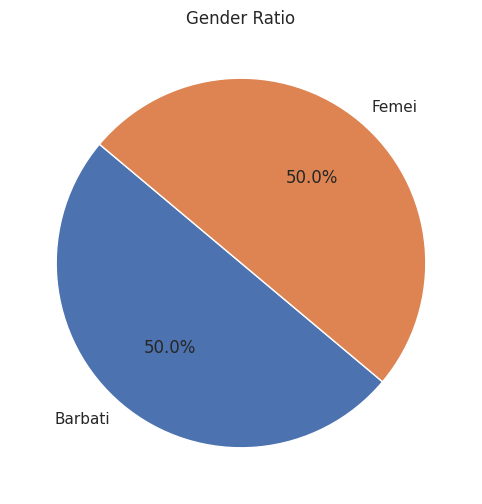

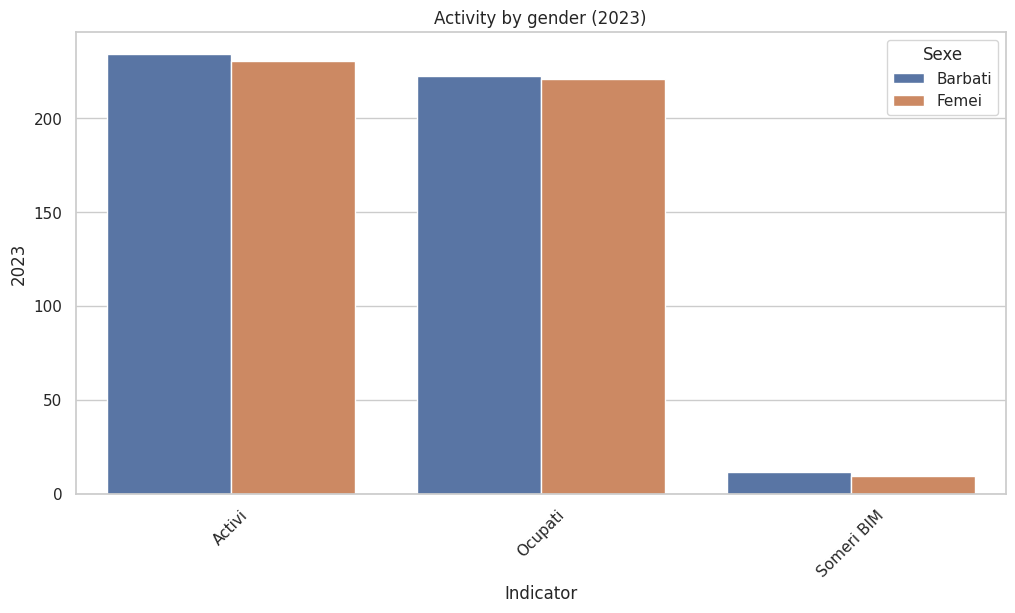

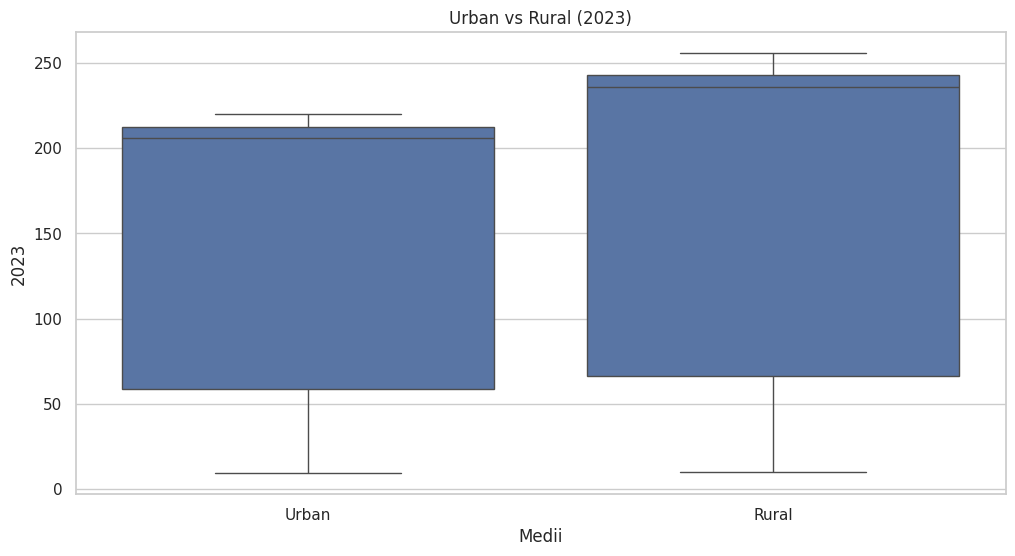

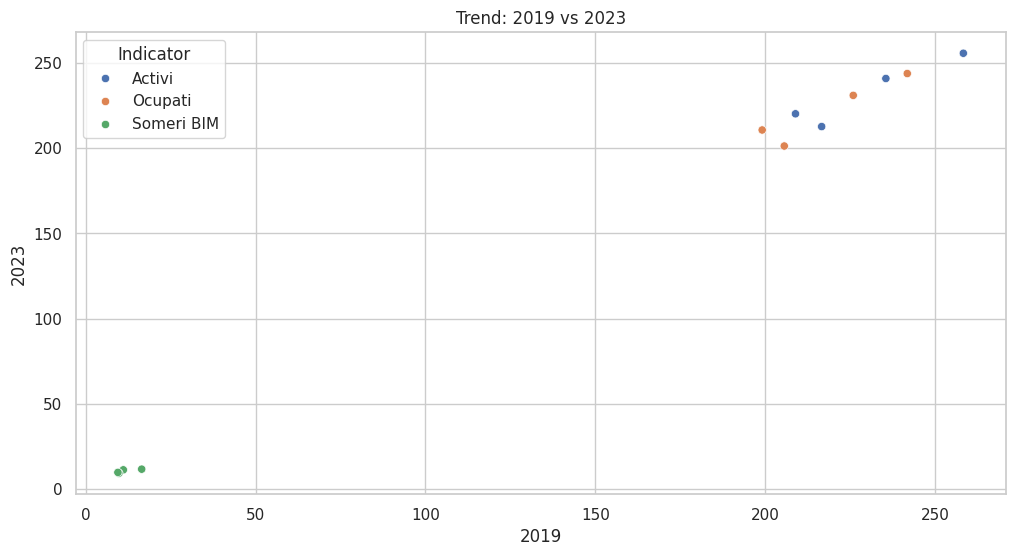

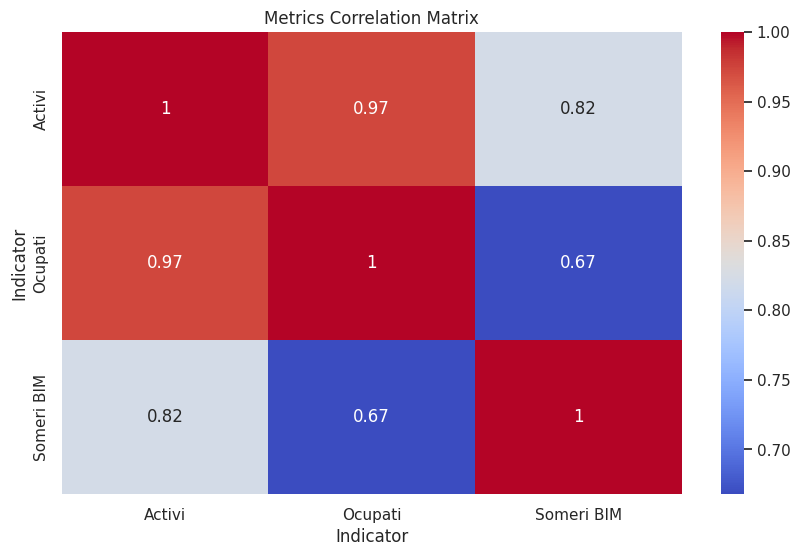

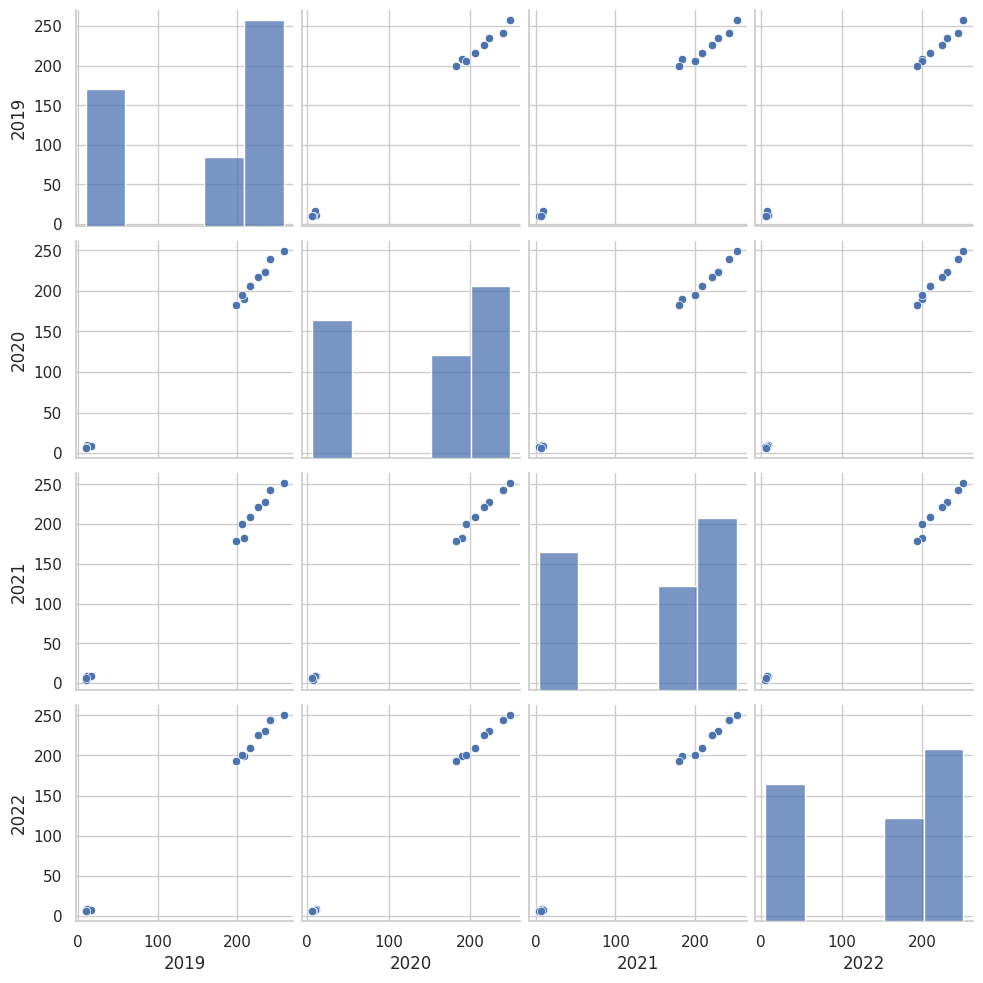


EDA completed. All categories are processed.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]


df = pd.read_csv(filename, sep=';', skiprows=2)


df.columns.values[0] = 'Indicator'
df.columns.values[1] = 'Sexe'
df.columns.values[2] = 'Medii'

df['Indicator'] = df['Indicator'].fillna(method='ffill')
df['Sexe'] = df['Sexe'].fillna(method='ffill')
df['Medii'] = df['Medii'].fillna(method='ffill')


df = df.dropna(subset=[df.columns[3]])

for col in df.columns[3:]:
    df[col] = df[col].astype(str).str.replace(',', '.').str.replace(' ', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df[
    (df['Sexe'] != 'Ambele sexe') &
    (df['Medii'] != 'Total pe tara') &
    (df['Indicator'] != 'Total')
].copy()

df_clean.to_csv("cleaned_moldova_statistics.csv", index=False)

target_col = '2023'

plt.figure()
sns.histplot(df_clean[target_col].dropna(), kde=True, color='skyblue')
plt.title(f'Distribution for {target_col}')
plt.show()

plt.figure()
sns.boxplot(x=df_clean[target_col].dropna(), color='lightcoral')
plt.title(f'Outliers check: {target_col}')
plt.show()

plt.figure()
df_clean['Sexe'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Gender Ratio')
plt.ylabel('')
plt.show()

plt.figure()
sns.barplot(data=df_clean, x='Indicator', y=target_col, hue='Sexe', ci=None)
plt.title(f'Activity by gender ({target_col})')
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.boxplot(data=df_clean, x='Medii', y=target_col)
plt.title(f'Urban vs Rural ({target_col})')
plt.show()


plt.figure()
sns.scatterplot(data=df_clean, x='2019', y='2023', hue='Indicator')
plt.title('Trend: 2019 vs 2023')
plt.show()

# Corr.
yearly_cols = [c for c in df.columns if not c.startswith('Unnamed') and c not in ['Indicator', 'Sexe', 'Medii']]

pivot_table = df_clean.pivot_table(
    index='Indicator',
    values=yearly_cols,
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table.T.corr(), annot=True, cmap='coolwarm')
plt.title("Metrics Correlation Matrix")
plt.show()

sns.pairplot(df_clean[yearly_cols[:4]])
plt.show()

print("\nEDA completed. All categories are processed.")

In [11]:

yearly_cols = [c for c in df.columns if c.isdigit()]


valid_years = [col for col in yearly_cols if df_clean[col].notna().any()]


summary_table = df_clean[valid_years].describe().T
summary_table['median'] = df_clean[valid_years].median()

summary_table.columns = ['Кол-во', 'Среднее', 'Ср.откл', 'Мин', '25%', '50%(Мед)', '75%', 'Макс', 'Медиана']

print("--- ИТОГОВАЯ ТАБЛИЦА (только актуальные данные) ---")
display(summary_table.round(2))

summary_table.to_excel("statistica_summary.xlsx")

--- ИТОГОВАЯ ТАБЛИЦА (только актуальные данные) ---


,Кол-во,Среднее,Ср.откл,Мин,25%,50%(Мед),75%,Макс,Медиана
2019,12.0,153.22,105.75,9.5,15.15,207.25,228.30,258.3,207.25
2020,12.0,144.56,102.42,6.2,10.12,192.40,218.65,248.8,192.40
2021,12.0,145.28,104.28,4.0,8.98,191.60,223.10,252.0,191.60
2022,12.0,148.34,105.88,5.5,8.62,199.55,226.45,251.0,199.55
2023,12.0,154.90,107.61,9.4,11.70,211.70,233.48,255.7,211.70
2024,12.0,148.18,103.17,7.4,9.43,213.60,221.00,229.3,213.60
